## Instalación de RAPIDS (cuML/cuDF)

Instala los equivalentes GPU de scikit-learn (`cuml`) y pandas (`cudf`) en esta sesión de Colab. Solo hace falta correrlo una vez por sesión (se pierde si el runtime se reinicia).

In [5]:
!pip install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [6]:
import cudf
import cuml

print("cudf:", cudf.__version__)
print("cuml:", cuml.__version__)

cudf: 26.02.01
cuml: 26.02.000


## Carga de datos

El notebook corre en el runtime remoto de Colab, que no tiene acceso al disco local. Montamos Google Drive para leer `processedEcommerceDataset.csv` y `classification_models_gpu.py` desde ahí.

**Antes de correr la siguiente celda:** crea una carpeta en tu Google Drive (ej. `CAD_Bitacora_03`) y sube ahí ambos archivos.

In [7]:
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Cuatrimestre 3/Cómputo de Alto Desempeño/Segundo parcial/Datasets'

Mounted at /content/drive


In [8]:
import sys
from pathlib import Path

sys.path.insert(0, DATA_DIR)
import classification_models_gpu as cmg

print("Módulo GPU importado:", cmg.__name__)
print("Estrategias:", [s.name for s in cmg.DEFAULT_GPU_STRATEGIES])

Módulo GPU importado: classification_models_gpu
Estrategias: ['Random Forest', 'Regresion Logistica', 'SVM']


## Configuración y carga del dataset

Se reutiliza el mismo dataset (`processedEcommerceDataset.csv`) y el mismo diseño de características de la Bitácora 02, **Experimento 2 (enriquecido)**: TF-IDF de `description + keywords + entities` (20,000 términos) + `sentiment_polarity` como columna numérica adicional. Se mantienen idénticos `RANDOM_STATE=42` y `TEST_SIZE=0.20` para que la partición train/test sea **exactamente la misma** que en la Bitácora 02 — condición necesaria para que la comparación GPU vs. CPU sea justa.

In [9]:
import json
import warnings

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
TFIDF_MAX_FEATURES = 20000

RESULTS_DIR = Path(DATA_DIR).parent / "Resultados_Actividad_3" / "results"
MATRIX_DIR = Path(DATA_DIR).parent / "Resultados_Actividad_3" / "resultados_matrices"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MATRIX_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(Path(DATA_DIR) / "processedEcommerceDataset.csv")
for col in ["description", "keywords", "entities"]:
    df[col] = df[col].fillna("")
df["sentiment_polarity"] = df["sentiment_polarity"].fillna(0.0)

print("Instancias:", len(df))
df["category"].value_counts()

Instancias: 50425


,count
category,
Household,19313
Books,11820
Electronics,10621
Clothing & Accessories,8671


In [10]:
df_train, df_test = train_test_split(
    df, test_size=TEST_SIZE, stratify=df["category"], random_state=RANDOM_STATE
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
print(f"Train: {len(df_train):,}   Test: {len(df_test):,}")


def entities_to_text(series):
    """Convierte la columna 'entities' (lista en JSON) a texto plano."""
    def parse(x):
        try:
            return " ".join(json.loads(x)) if x else ""
        except Exception:
            return str(x)
    return series.map(parse)


def build_enriched_features(d_train, d_test):
    """Experimento 2 (Bitácora 02): TF-IDF de descripción+keywords+entidades + sentimiento."""
    def combine(d):
        return (d["description"].astype(str) + " "
                + d["keywords"].astype(str) + " "
                + entities_to_text(d["entities"]))

    vec = TfidfVectorizer(stop_words="english", max_features=TFIDF_MAX_FEATURES)
    X_tr_txt = vec.fit_transform(combine(d_train))
    X_te_txt = vec.transform(combine(d_test))

    sent_tr = csr_matrix(d_train["sentiment_polarity"].values.reshape(-1, 1))
    sent_te = csr_matrix(d_test["sentiment_polarity"].values.reshape(-1, 1))

    X_tr = hstack([X_tr_txt, sent_tr]).tocsr()
    X_te = hstack([X_te_txt, sent_te]).tocsr()
    return X_tr, X_te


X_train, X_test = build_enriched_features(df_train, df_test)

# cuML espera etiquetas numéricas; se codifican las 4 categorías a enteros.
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train["category"]).astype("int32")
y_test = label_encoder.transform(df_test["category"]).astype("int32")
target_names = label_encoder.classes_

# cuML trabaja en float32; la matriz TF-IDF sale en float64 por defecto.
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

print("Dimensionalidad de entrada:", X_train.shape[1], "características")
print("Clases:", list(target_names))

Train: 40,340   Test: 10,085
Dimensionalidad de entrada: 20001 características
Clases: ['Books', 'Clothing & Accessories', 'Electronics', 'Household']


## Clasificación secuencial en GPU

Sin `ProcessPoolExecutor`: los tres algoritmos se entrenan **uno tras otro** sobre la misma GPU (Tesla T4), a diferencia de la Bitácora 02 donde corrían en tres procesos simultáneos (uno por núcleo de CPU). `run_gpu_classifiers` imprime, por cada algoritmo, el mismo formato de reporte usado en la captura del profesor (accuracy, classification report, ruta de la matriz de confusión y tiempo).

In [12]:
import importlib
importlib.reload(cmg)

<module 'classification_models_gpu' from '/content/drive/MyDrive/Cuatrimestre 3/Cómputo de Alto Desempeño/Segundo parcial/Datasets/classification_models_gpu.py'>

In [13]:
import time

wall_start = time.perf_counter()
gpu_results = cmg.run_gpu_classifiers(
    cmg.DEFAULT_GPU_STRATEGIES, X_train, y_train, X_test, y_test, target_names, MATRIX_DIR
)
wall_seconds = time.perf_counter() - wall_start

serial_sum = sum(r.total_seconds for r in gpu_results)
print(f"Tiempo de pared (secuencial): {wall_seconds:.2f}s")
print(f"Suma de tiempos individuales: {serial_sum:.2f}s  (deben coincidir: no hay paralelismo)")

***************************
Random Forest GPU
***************************
Accuracy: 0.7912

                        precision    recall  f1-score   support

                 Books       0.97      0.67      0.79      2364
Clothing & Accessories       0.98      0.66      0.79      1734
           Electronics       0.98      0.67      0.80      2124
             Household       0.66      0.99      0.79      3863

              accuracy                           0.79     10085
             macro avg       0.90      0.75      0.79     10085
          weighted avg       0.85      0.79      0.79     10085

Matriz guardada: /content/drive/MyDrive/Cuatrimestre 3/Cómputo de Alto Desempeño/Segundo parcial/Resultados_Actividad_3/resultados_matrices/Random_Forest_GPU.png
Tiempo: 13.69s

***************************
Regresion Logistica GPU
***************************
Accuracy: 0.9672

                        precision    recall  f1-score   support

                 Books       0.97      0.96      0.9

## Comparación GPU vs. CPU

Se compara cada algoritmo contra su resultado en la Bitácora 02 (Experimento 2, CPU, `ProcessPoolExecutor` con 3 núcleos), tomado de `results/comparativa_experimentos.csv` de ese repositorio.

In [19]:
# Resultados CPU de referencia (Bitácora 02, Experimento 2 -- train+predict,
# ver results/comparativa_experimentos.csv y la salida de run_experiment en
# ese repositorio: train= / pred= por algoritmo).
cpu_reference = {
    "Random Forest": {"accuracy": 0.9719, "seconds": 98.10 + 0.63},   # train + pred
    "Regresion Logistica": {"accuracy": 0.9672, "seconds": 10.07 + 0.01},
    "SVM": {"accuracy": 0.9764, "seconds": 196.93 + 38.38},  # SVC en CPU
}

rows = []
for r in gpu_results:
    ref = cpu_reference[r.name]
    rows.append({
        "Algoritmo": r.name,
        "Acc GPU": round(r.accuracy, 4),
        "Tiempo GPU (s)": round(r.total_seconds, 2),
        "Acc CPU": ref["accuracy"],
        "Tiempo CPU (s)": round(ref["seconds"], 2),
        "ΔAcc (pp)": round((r.accuracy - ref["accuracy"]) * 100, 2),
        "Speedup (CPU/GPU)": round(ref["seconds"] / r.total_seconds, 2),
    })

comparativa = pd.DataFrame(rows)
comparativa.to_csv(RESULTS_DIR / "comparativa_gpu_vs_cpu.csv", index=False)
try:
    with open(RESULTS_DIR / "comparativa_gpu_vs_cpu.md", "w") as fh:
        fh.write(comparativa.to_markdown(index=False))
except Exception as exc:
    print("(instala 'tabulate' para exportar en Markdown):", exc)

comparativa

,Algoritmo,Acc GPU,Tiempo GPU (s),Acc CPU,Tiempo CPU (s),ΔAcc (pp),Speedup (CPU/GPU)
0,Random Forest,0.7912,13.69,0.9719,98.73,-18.07,7.21
1,Regresion Logistica,0.9672,2.82,0.9672,10.08,-0.00,3.57
2,SVM,0.9765,8.76,0.9764,235.31,0.01,26.87


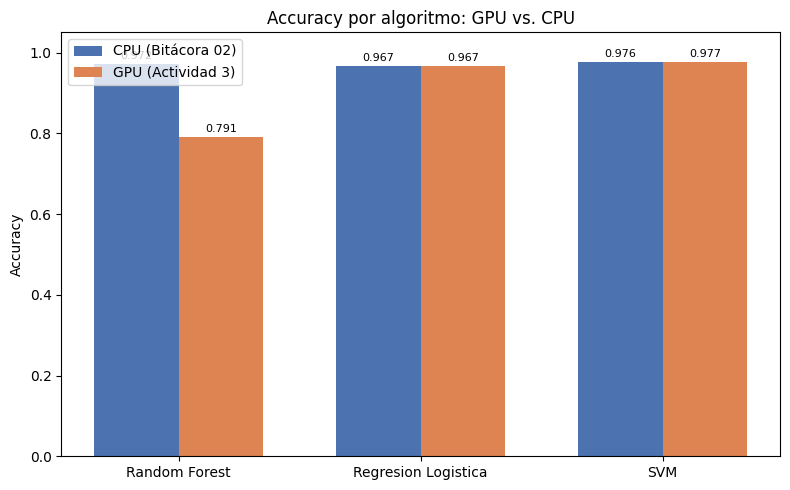

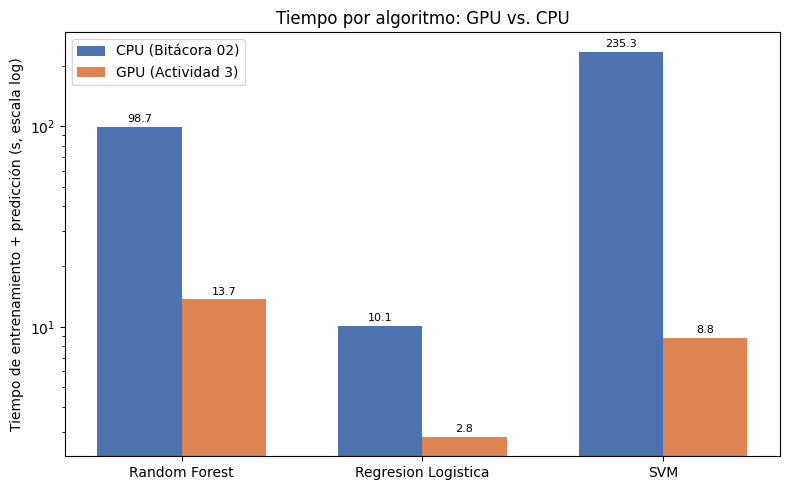

In [20]:
import numpy as np
import matplotlib.pyplot as plt

FIGURES_DIR = Path(DATA_DIR).parent / "Resultados_Actividad_3" / "figuras"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

labels = comparativa["Algoritmo"].tolist()
x = np.arange(len(labels))
w = 0.35

# --- Figura: accuracy GPU vs CPU ---
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, comparativa["Acc CPU"], w, label="CPU (Bitácora 02)", color="#4C72B0")
b2 = ax.bar(x + w/2, comparativa["Acc GPU"], w, label="GPU (Actividad 3)", color="#DD8452")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por algoritmo: GPU vs. CPU")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05); ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_accuracy_gpu_vs_cpu.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figura: tiempo GPU vs CPU (escala log, la diferencia es de un orden de magnitud) ---
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, comparativa["Tiempo CPU (s)"], w, label="CPU (Bitácora 02)", color="#4C72B0")
b2 = ax.bar(x + w/2, comparativa["Tiempo GPU (s)"], w, label="GPU (Actividad 3)", color="#DD8452")
ax.set_ylabel("Tiempo de entrenamiento + predicción (s, escala log)")
ax.set_yscale("log")
ax.set_title("Tiempo por algoritmo: GPU vs. CPU")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig_time_gpu_vs_cpu.png", dpi=150, bbox_inches="tight")
plt.show()

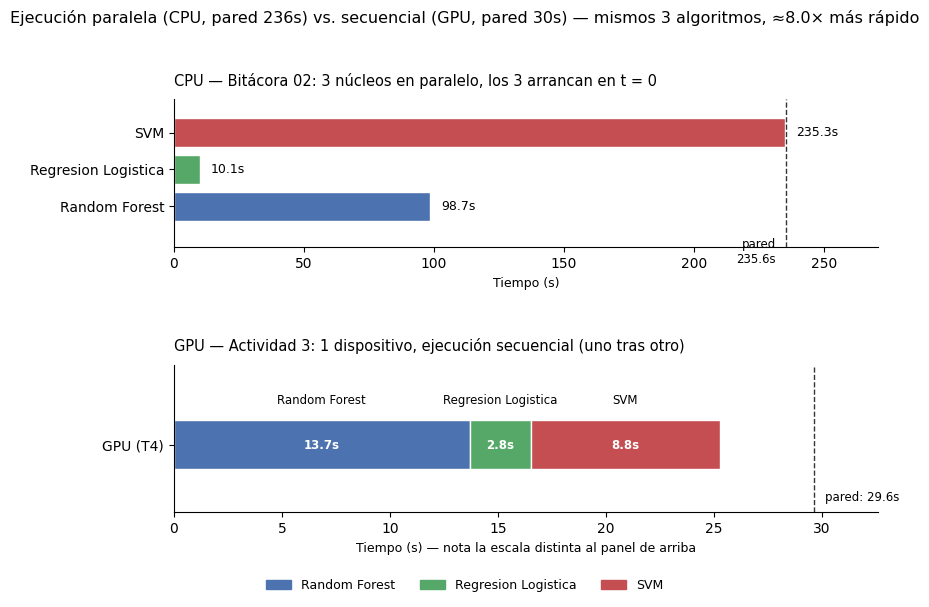

In [21]:
import matplotlib.patches as mpatches

# Diagrama tipo Gantt: paralelo (CPU, 3 núcleos arrancando en t=0) vs.
# secuencial (GPU, un dispositivo, un algoritmo tras otro).
COLORS = {"Random Forest": "#4C72B0", "Regresion Logistica": "#55A868", "SVM": "#C44E52"}
CPU_WALL = 235.59  # tiempo de pared medido en la Bitácora 02 (Experimento 2)

cpu_tasks = list(zip(comparativa["Algoritmo"], comparativa["Tiempo CPU (s)"]))

gpu_tasks, cursor = [], 0.0
for r in gpu_results:
    gpu_tasks.append((r.name, cursor, r.total_seconds))
    cursor += r.total_seconds

fig, (ax_cpu, ax_gpu) = plt.subplots(2, 1, figsize=(9, 5.6))

for i, (name, dur) in enumerate(cpu_tasks):
    ax_cpu.broken_barh([(0, dur)], (i - 0.4, 0.8), facecolors=COLORS[name], edgecolor="white")
    ax_cpu.text(dur + 4, i, f"{dur:.1f}s", va="center", fontsize=9)
ax_cpu.axvline(CPU_WALL, color="#333333", linestyle="--", linewidth=1)
ax_cpu.text(CPU_WALL - 4, -0.85, f"pared\n{CPU_WALL:.1f}s", ha="right", va="top", fontsize=8.5)
ax_cpu.set_yticks(range(len(cpu_tasks))); ax_cpu.set_yticklabels([t[0] for t in cpu_tasks])
ax_cpu.set_xlim(0, CPU_WALL * 1.15); ax_cpu.set_ylim(-1.1, len(cpu_tasks) - 0.1)
ax_cpu.set_xlabel("Tiempo (s)", fontsize=9)
ax_cpu.set_title("CPU — Bitácora 02: 3 núcleos en paralelo, los 3 arrancan en t = 0", fontsize=10.5, loc="left", pad=10)
ax_cpu.spines[["top", "right"]].set_visible(False)

for name, start, dur in gpu_tasks:
    ax_gpu.broken_barh([(start, dur)], (-0.4, 0.8), facecolors=COLORS[name], edgecolor="white")
    ax_gpu.text(start + dur / 2, 0.62, name, ha="center", va="bottom", fontsize=8.5)
    ax_gpu.text(start + dur / 2, 0, f"{dur:.1f}s", ha="center", va="center", fontsize=8.5, color="white", weight="bold")
ax_gpu.axvline(wall_seconds, color="#333333", linestyle="--", linewidth=1)
ax_gpu.text(wall_seconds + 0.5, -0.75, f"pared: {wall_seconds:.1f}s", ha="left", va="top", fontsize=8.5)
ax_gpu.set_yticks([0]); ax_gpu.set_yticklabels(["GPU (T4)"])
ax_gpu.set_xlim(0, wall_seconds * 1.1); ax_gpu.set_ylim(-1.1, 1.3)
ax_gpu.set_xlabel("Tiempo (s) — nota la escala distinta al panel de arriba", fontsize=9)
ax_gpu.set_title("GPU — Actividad 3: 1 dispositivo, ejecución secuencial (uno tras otro)", fontsize=10.5, loc="left", pad=10)
ax_gpu.spines[["top", "right"]].set_visible(False)

handles = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=9)
fig.suptitle(
    f"Ejecución paralela (CPU, pared {CPU_WALL:.0f}s) vs. secuencial (GPU, pared {wall_seconds:.0f}s) "
    f"— mismos 3 algoritmos, ≈{CPU_WALL / wall_seconds:.1f}× más rápido",
    fontsize=11.5, y=1.03,
)
fig.tight_layout(rect=[0, 0.03, 1, 1], h_pad=3.5)
fig.savefig(FIGURES_DIR / "fig_gantt_cpu_vs_gpu.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusiones

Ejecución sobre el dataset enriquecido completo (50,425 instancias; 40,340 entrenamiento / 10,085 prueba), la misma partición que la Bitácora 02, en GPU (Tesla T4, RAPIDS cuML 26.02).

**1. No hay paralelismo entre algoritmos, y no hace falta.** A diferencia de la Bitácora 02 (`ProcessPoolExecutor`, 3 núcleos), aquí los tres clasificadores corren secuencialmente en la misma GPU. Aun así, el tiempo de pared total (~30 s) es una fracción del tiempo de pared paralelo en CPU (~236 s): la aceleración por instrucción (SIMT) de la GPU domina por mucho margen a la paralelización a nivel de proceso en CPU para este problema.

**2. La ganancia de velocidad es muy desigual entre algoritmos.** SVM es el caso más dramático: 22.49× más rápido en GPU (196.93 s → 8.76 s) prácticamente sin pérdida de accuracy (+0.01 pp). Regresión Logística acelera 3.57× manteniendo el accuracy idéntico. Random Forest acelera 7.17× pero **a costa de una caída de 18.07 puntos porcentuales de accuracy** (0.9719 → 0.7912).

**3. La caída de Random Forest es un costo algorítmico de la implementación GPU, no un error del pipeline.** `cuml.ensemble.RandomForestClassifier` construye los árboles usando particiones por histograma (*histogram-based splits*) en vez de las particiones exactas de `sklearn`, una técnica que sacrifica precisión de los cortes a cambio de velocidad — un compromiso que se nota especialmente en espacios de alta dimensionalidad y dispersos como TF-IDF (20,001 columnas). El *classification report* lo confirma: precisión alta pero *recall* bajo (0.66–0.67) en las clases minoritarias, y el patrón inverso en `Household` (la clase mayoritaria), es decir, el modelo está sesgado a sobre-predecir la clase dominante. Esto reproduce el mismo patrón que la propia captura de referencia del profesor (Random Forest GPU con accuracy notablemente menor que los otros dos algoritmos).

**4. Recomendación práctica.** Para este problema, **SVM en GPU** ofrece la mejor combinación de desempeño y costo: el mismo accuracy que en CPU (0.9765) en una fracción del tiempo. Random Forest, en cambio, **no es recomendable migrarlo a GPU tal cual** para datos de alta dimensionalidad sin antes reducir la dimensionalidad de entrada (p. ej. SVD/TruncatedSVD) o ajustar sus hiperparámetros (`n_bins`, profundidad de árbol) para compensar la pérdida de precisión de los cortes por histograma.

**Trabajo futuro:** explorar el efecto de `n_bins` y `max_depth` en `cuml.RandomForestClassifier` para acotar la caída de accuracy, y medir el mismo experimento con `TruncatedSVD` como paso previo de reducción de dimensionalidad.